In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

2361535


In [2]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [23]:
def build_graph(filename, sequence, score_map, distance_map=None, sep_min=0):
    
    N = len(sequence)

    # score map to tensor
    score_map = torch.tensor(score_map, dtype=torch.float)
    #score_map = torch.log(score_map + 1.0)  #renormalization to see again when we have more data
    #score_map = (score_map - score_map.mean()) / (score_map.std() + 1e-6)
    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    sep = torch.abs(i - j).float()
    sep_bucket = torch.clamp(sep, max=32).long()


    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        distance_map = torch.tensor(distance_map, dtype=torch.float)
        distance_map=torch.log((distance_map)/8) #renormalization to see again when we have more data
        known = torch.isfinite(distance_map)
        labels = distance_map
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok

    # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    # after you create src, dst for all i != j
    edge_to_idx = {(int(s), int(d)): k for k, (s, d) in enumerate(zip(src.tolist(), dst.tolist()))}
    rev_edge_idx = torch.tensor([edge_to_idx[(int(d), int(s))] for s, d in zip(src.tolist(), dst.tolist())],dtype=torch.long)

    edge_index = torch.stack([src, dst], dim=0)

    #edge_attr = score_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1)

    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        #edge_attr=edge_attr,
        edge_attr = torch.stack([score_map[valid],sep_bucket[valid].float()], dim=-1),
        y=y,
        edge_mask=mask,
        pair_mask=pair_mask,
        rev_edge_idx=rev_edge_idx,
        L=N,
        filename=filename
    )

In [24]:
folder_path = "Data_C_alpha"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):    #and (file== "data_PF00014.pkl" or file== "data_PF01640.pkl")
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        filename=str(file)
        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph(filename,sequence, contact_map_DCA, distance_map)
        all_data.append(data)


from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# train_loader=DataLoader(all_data, batch_size=1, shuffle=True) 
# test_loader=DataLoader(all_data, batch_size=1, shuffle=True) 

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=0)


train_loader = DataLoader(train_data, batch_size=1, shuffle=True) 
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [5]:
print(train_loader)

with torch.no_grad():
    for batch in train_loader:
        print(batch)

DataBatch(x=[93, 16], edge_index=[2, 8556], edge_attr=[8556, 2], y=[8556, 1], edge_mask=[8556], pair_mask=[8556], rev_edge_idx=[8556], filename=[1], batch=[93], ptr=[2])
DataBatch(x=[180, 16], edge_index=[2, 32220], edge_attr=[32220, 2], y=[32220, 1], edge_mask=[32220], pair_mask=[32220], rev_edge_idx=[32220], filename=[1], batch=[180], ptr=[2])
DataBatch(x=[102, 16], edge_index=[2, 10302], edge_attr=[10302, 2], y=[10302, 1], edge_mask=[10302], pair_mask=[10302], rev_edge_idx=[10302], filename=[1], batch=[102], ptr=[2])
DataBatch(x=[103, 16], edge_index=[2, 10506], edge_attr=[10506, 2], y=[10506, 1], edge_mask=[10506], pair_mask=[10506], rev_edge_idx=[10506], filename=[1], batch=[103], ptr=[2])
DataBatch(x=[204, 16], edge_index=[2, 41412], edge_attr=[41412, 2], y=[41412, 1], edge_mask=[41412], pair_mask=[41412], rev_edge_idx=[41412], filename=[1], batch=[204], ptr=[2])
DataBatch(x=[127, 16], edge_index=[2, 16002], edge_attr=[16002, 2], y=[16002, 1], edge_mask=[16002], pair_mask=[16002]

In [60]:
#original

import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out
    
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, sep_emb_dim = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:

            self.sep_embedding = nn.Embedding(33, sep_emb_dim) #bucket to have relative distance between point in the chain
            self.edge_embed = nn.Sequential(
                nn.Linear(1+sep_emb_dim, hidden_ch),
                nn.ReLU(),
                nn.Linear(hidden_ch, hidden_ch),
            )
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = hidden_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente
        
        # --- split edge features ---
        score = edge_attr[:, 0:1]                     # [E, 1]
        sep_bucket = edge_attr[:, 1].long()           # [E]

        # --- embed separation ---
        sep_emb = self.sep_embedding(sep_bucket)      # [E, sep_emb_dim]

        # --- combine ---
        edge_attr = torch.cat([score, sep_emb], dim=-1)

        # --- embed once ---
        edge_attr = self.edge_embed(edge_attr)

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr
            
            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)

            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)
            
        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [6]:
#dropout
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            #nn.Dropout(p=0.2),    #dropout
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            #nn.Dropout(p=0.2),    #dropout
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out
    


from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, sep_emb_dim = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:

            self.sep_embedding = nn.Embedding(33, sep_emb_dim) #bucket to have relative distance between point in the chain
            self.edge_embed = nn.Sequential(
                nn.Linear(1+sep_emb_dim, hidden_ch),
                nn.ReLU(),
                #nn.Dropout(p=0.2),    #dropout
                nn.Linear(hidden_ch, hidden_ch),
            )
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = hidden_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            #nn.Dropout(p=0.2),    #dropout
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente
        
        # --- split edge features ---
        score = edge_attr[:, 0:1]                     # [E, 1]
        sep_bucket = edge_attr[:, 1].long()           # [E]

        # --- embed separation ---
        sep_emb = self.sep_embedding(sep_bucket)      # [E, sep_emb_dim]

        # --- combine ---
        edge_attr = torch.cat([score, sep_emb], dim=-1)

        # --- embed once ---
        edge_attr = self.edge_embed(edge_attr)

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr
            
            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            x = F.dropout(x, p=0.1, training=self.training) #dropout

            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)
            edge_attr = F.dropout(edge_attr, p=0.1, training=self.training)     #dropout
        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [7]:
def triangle_inequality_loss_sampled(pred_dist_matrix, mask_matrix, num_samples=10000):
    B, N, _ = pred_dist_matrix.shape
    device = pred_dist_matrix.device
    # Randomly pick i, j, k indices
    i = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    j = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    k = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    
    d_ij = torch.exp(pred_dist_matrix[:, i, j])
    d_ik = torch.exp(pred_dist_matrix[:, i, k])
    d_kj = torch.exp(pred_dist_matrix[:, k, j])

    # d_ij = pred_dist_matrix[:, i, j]
    # d_ik = pred_dist_matrix[:, i, k]
    # d_kj = pred_dist_matrix[:, k, j]

    valid = (
        mask_matrix[:, i, j] &
        mask_matrix[:, i, k] &
        mask_matrix[:, k, j])
    
    violations = torch.relu(d_ij - (d_ik + d_kj))
    violations = violations[valid]
    if violations.numel() == 0:
        return torch.tensor(0.0, device=device)

    return torch.mean(violations**2)

In [8]:
from torch_geometric.utils import to_dense_adj
def compute_loss(batch, pred_dist, true_dist, epoch=0):
    valid = batch.edge_mask #& batch.pair_mask

    # separation bucket is already in edge_attr[:, 1]
    sep = batch.edge_attr[:, 1].long()

    # example: ignore very local pairs, upweight long-range ones
    weights = torch.ones_like(true_dist)

    # if epoch<30:
    #     weights[sep < 6] = 0.0
    # else:
    #     weights[sep < 6] = 0.5  # very local


    weights[sep < 6] = 2.0
    weights[(sep >= 6) & (sep < 12)] = 3.0
    weights[sep >= 12] = 5.0        # long-range

    per_edge = F.smooth_l1_loss(
        pred_dist[valid],
        true_dist[valid],
        beta=0.1,
        reduction='none'
    )

    main_loss = (weights[valid] * per_edge).sum() / (weights[valid].sum()+1e-8)

    sym_loss = F.mse_loss(
        pred_dist[valid],
        pred_dist[batch.rev_edge_idx][valid]
    )

    dense_pred = to_dense_adj(batch.edge_index, batch.batch, edge_attr=pred_dist)
    dense_mask = to_dense_adj(batch.edge_index, batch.batch, edge_attr=batch.edge_mask.float()).bool()
    tri_loss = triangle_inequality_loss_sampled(dense_pred, dense_mask)

    λ_sym = min(0.1, epoch / 50 * 0.1)

    if epoch < 50:
        λ_tri = 0.0
    else:
        λ_tri = min(0.01, (epoch - 50) / 100 * 0.01)

    loss = main_loss + λ_sym * sym_loss + λ_tri * tri_loss
    
    return loss

#loss più fporte quando sbaglia
#inverse participation ratio

In [ ]:
# device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
# model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)
#save_path = "best_model_regressor.pt"

In [ ]:
# device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
# model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=64, mlp_hidden_ch=32, GNN_layers=3).to(device)

# save_path = "best_model_regressor_3.pt"

In [9]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)

save_path = "best_model_regressor_c_alpha_drop.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)



##controllare parametri, valore medio sul grafo o da un valore diverso ad ogni edge? In tal modo quelle grosse sonon molto più pesanti e rilevanti (dividere per numero do edge???)
#vedere sec'e un  modo per meedialre la loss sugli edge (moduli di torch geometric o torch scatter)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=20,min_lr=1e-6)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 1000
epochs_no_improve = 0

for epoch in range(10000): 

    model.train()
    total_loss = 0.0
    total_edges = 0

    for batch in train_loader:
        batch = batch.to(device) 

        optimizer.zero_grad() 
        _, pred_dist = model(batch)

        mask = batch.edge_mask
        true_dist = batch.y.squeeze(-1)
        pred_dist = pred_dist.squeeze(-1)

        loss=compute_loss(batch,pred_dist,true_dist,epoch)
        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  #gradient clipping
        optimizer.step()
    
    train_loss = total_loss / max(total_edges, 1)
    
    model.eval()
    total_loss_val = 0.0
    total_edges_val = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)

            _, pred_dist = model(batch)
            pred_dist = pred_dist.squeeze(-1)
            true_dist = batch.y.squeeze(-1)
            mask = batch.edge_mask

            loss=compute_loss(batch,pred_dist,true_dist,epoch)

            n_edges = mask.sum().item()
            total_loss_val += loss.item() * n_edges
            total_edges_val += n_edges
    

    val_loss= total_loss_val / max(total_edges_val, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break



Epoch 0: Train Loss=0.3015, Val Loss=0.2756
Epoch 1: Train Loss=0.2800, Val Loss=0.2748
Epoch 2: Train Loss=0.2780, Val Loss=0.2779
Epoch 3: Train Loss=0.2756, Val Loss=0.2706
Epoch 4: Train Loss=0.2736, Val Loss=0.2643
Epoch 5: Train Loss=0.2685, Val Loss=0.2642
Epoch 6: Train Loss=0.2648, Val Loss=0.2627
Epoch 7: Train Loss=0.2645, Val Loss=0.2644
Epoch 8: Train Loss=0.2629, Val Loss=0.2569
Epoch 9: Train Loss=0.2627, Val Loss=0.2613
Epoch 10: Train Loss=0.2614, Val Loss=0.2586
Epoch 11: Train Loss=0.2608, Val Loss=0.2564
Epoch 12: Train Loss=0.2593, Val Loss=0.2551
Epoch 13: Train Loss=0.2598, Val Loss=0.2555
Epoch 14: Train Loss=0.2596, Val Loss=0.2551
Epoch 15: Train Loss=0.2589, Val Loss=0.2547
Epoch 16: Train Loss=0.2595, Val Loss=0.2559
Epoch 17: Train Loss=0.2581, Val Loss=0.2560
Epoch 18: Train Loss=0.2578, Val Loss=0.2561
Epoch 19: Train Loss=0.2578, Val Loss=0.2573
Epoch 20: Train Loss=0.2574, Val Loss=0.2533
Epoch 21: Train Loss=0.2570, Val Loss=0.2649
Epoch 22: Train Loss

KeyboardInterrupt: 

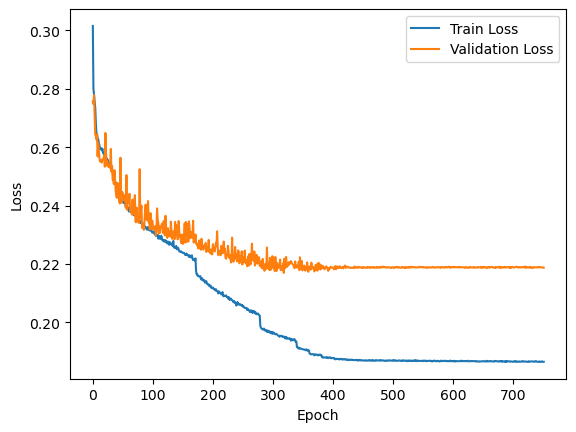

In [10]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [9]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = EdgeGNN(node_in_ch=16, sep_emb_dim=8, hidden_ch=128, mlp_hidden_ch=64, GNN_layers=4).to(device)

save_path = "best_model_regressor_c_alpha_drop.pt"
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [10]:
def graph_to_matrix(data, values, mask=None):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index

    if mask is not None:
        edge_index = edge_index[:, mask]
        values = values[mask]
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

In [11]:
def loss_per_graph(batch, pred_dist):
    scores = pred_dist.squeeze(-1)
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    loss_tot = []

    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        if g_scores.numel() == 0:
            continue

        loss = torch.mean(torch.abs((g_scores) - (g_true)))  # MAE per graph
        loss_tot.append(loss.item())

    return loss_tot

0.24690860755837116


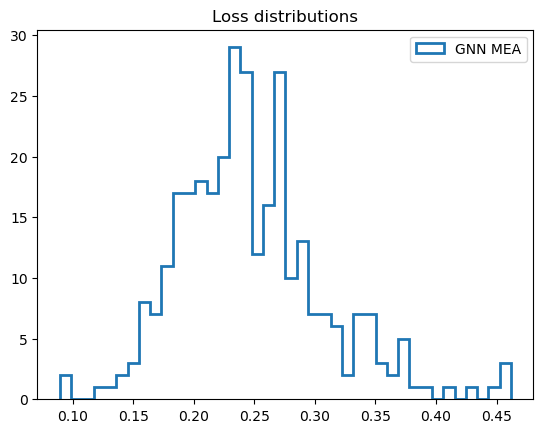

In [12]:
all_losses = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_dist = model(batch)

        loss_tot= loss_per_graph(batch,pred_dist)
        all_losses.extend(loss_tot)

print(np.mean(all_losses))

plt.hist(all_losses, bins=40, histtype='step',linewidth=2, label=f"GNN MEA")

plt.legend()
plt.title("Loss distributions")
plt.show()


In [13]:
sorted_losses = sorted(enumerate(all_losses), key=lambda x: x[1])

# First 3 minimum values and their indices
for idx, val in sorted_losses[:8]:
    print(val, idx)

for idx, val in sorted_losses[len(sorted_losses)-5:len(sorted_losses)]:
    print(val, idx)

0.08962881565093994 289
0.0918424054980278 165
0.12271592020988464 103
0.12712106108665466 18
0.14126966893672943 49
0.14425711333751678 39
0.15157383680343628 181
0.15253321826457977 10
0.4322882294654846 130
0.4522846043109894 64
0.45466724038124084 60
0.45683079957962036 32
0.4619053602218628 292


DataBatch(x=[111, 16], edge_index=[2, 12210], edge_attr=[12210, 2], y=[12210, 1], edge_mask=[12210], pair_mask=[12210], rev_edge_idx=[12210], filename=[1], batch=[111], ptr=[2])
['data_PF00072.pkl']


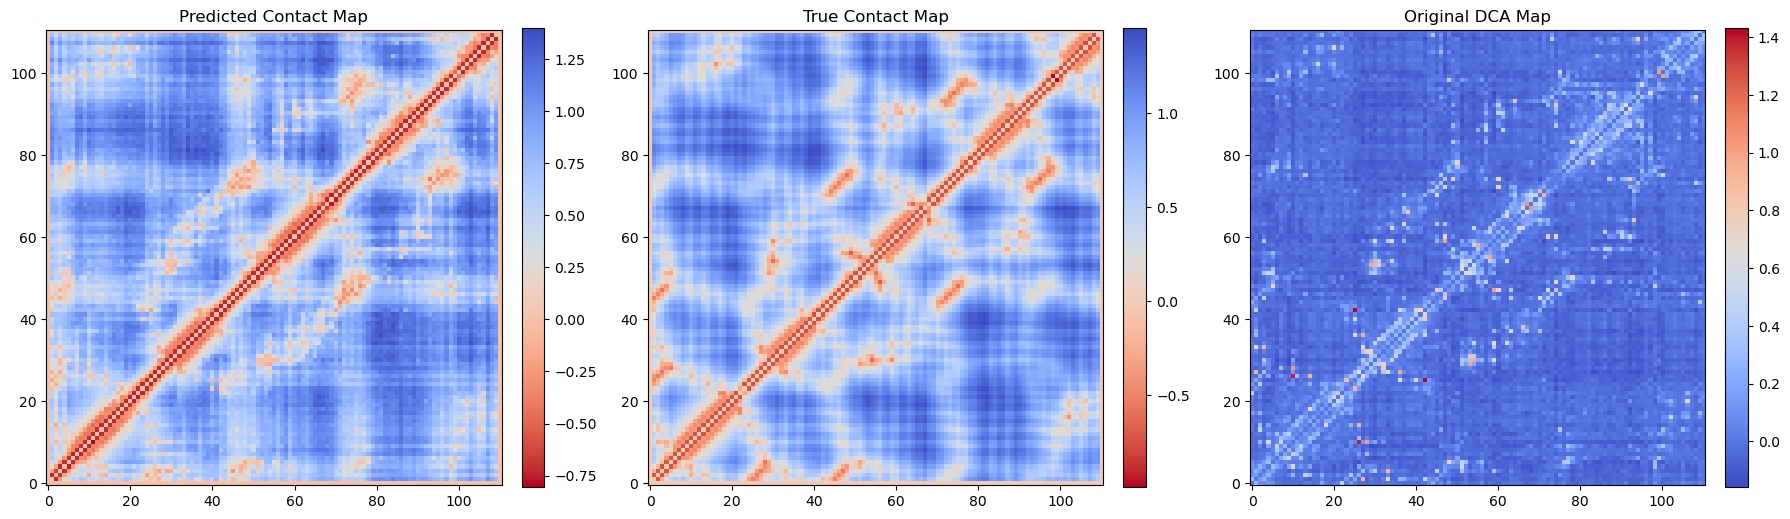

In [20]:
pos=39



i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_dist = model(batch)
            break
        i+=1

#batch=train_data[pos]
print(batch)
print(batch.filename)

mask = batch.edge_mask #& batch.pair_mask

pred_dist_map = graph_to_matrix(batch, pred_dist.squeeze(-1).cpu(), mask.cpu())
true_dist_map = graph_to_matrix(batch, batch.y.cpu(),mask.cpu())
original_dca_map = graph_to_matrix(batch, batch.edge_attr[:,0].cpu())


fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_dist_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---


im1 = axes[1].imshow(true_dist_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original DCA Map ---
im2 = axes[2].imshow(original_dca_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Original DCA Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [53]:
#option 1

import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X


def initial_fill_for_mds(D):
    """
    Fill missing distances for a good initial guess.
    """
    D = np.asarray(D, dtype=float)
    out = D.copy()

    finite = np.isfinite(out)
    finite_vals = out[finite & ~np.eye(out.shape[0], dtype=bool)]
    if finite_vals.size == 0:
        raise ValueError("No finite distances available for reconstruction.")

    fill_value = np.median(finite_vals) * 1.5
    out[~np.isfinite(out)] = fill_value
    out = 0.5 * (out + out.T)
    np.fill_diagonal(out, 0.0)
    return out


# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def reconstruct_3d_from_partial_distance_matrix(D, random_state=0, maxiter=800):
    """
    Reconstruct coordinates from a distance matrix that may contain inf entries.
    We minimize stress only over finite pairs.

    Returns:
        X: (N,3) coordinates
        stress: final MSE over observed pairs
        success: optimizer success flag
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D0 = initial_fill_for_mds(D)
    X0 = classical_mds(D0, n_components=3)

    iu = np.triu_indices(n, k=1)
    obs = np.isfinite(D[iu])
    i_idx = iu[0][obs]
    j_idx = iu[1][obs]
    target = D[i_idx, j_idx]

    def objective(x_flat):
        X = x_flat.reshape(n, 3)
        d = np.linalg.norm(X[i_idx] - X[j_idx], axis=1)
        return np.mean((d - target) ** 2)

    res = minimize(
        objective,
        X0.ravel(),
        method='L-BFGS-B',
        options={'maxiter': maxiter, 'ftol': 1e-10}
    )

    X = res.x.reshape(n, 3)
    return X, float(res.fun), bool(res.success)


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------

def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"

#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # Use only residues that are mapped and have enough finite constraints
    valid = (mi >= 1) & (np.isfinite(dm).sum(axis=1) > 1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    # Reconstruct 3D from the observed map
    X_rec, stress, success = reconstruct_3d_from_partial_distance_matrix(D_obs)

    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)

    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "optimizer_success": success,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }

#plot

def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")

In [20]:
#option2


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


#preprocess distance matrix 

def get_valid_mask(dm, mi, min_finite_per_row=1):
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residue exists in the mapped structure
    mapped = mi >= 1

    # residue has enough finite distances to be useful
    enough_contacts = np.isfinite(dm).sum(axis=1) >= min_finite_per_row

    return mapped & enough_contacts



# def preprocess_distance_matrix(D, q=0.98):
#     """
#     Symmetrize, remove infinities, and clip extreme values.
#     """
#     D = np.asarray(D, dtype=float)
#     D = 0.5 * (D + D.T)
#     np.fill_diagonal(D, 0.0)

#     finite = np.isfinite(D) & (D > 0)
#     vals = D[finite]

#     if vals.size == 0:
#         raise ValueError("No finite distances in matrix.")

#     fill_value = np.median(vals)
#     upper = np.quantile(vals, q)

#     D2 = D.copy()
#     D2[~np.isfinite(D2)] = fill_value  #########invece che il gap mette un valore medio, non sono sicuro vada molto bene
#     D2 = np.clip(D2, 0.0, upper)

#     return D2



# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X



# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def huber_loss(r, delta=1.0):
    """
    Robust loss for residuals.
    """
    a = np.abs(r)
    return np.where(a <= delta, 0.5 * r * r, delta * (a - 0.5 * delta))


def robust_reconstruct_3d(
    D,
    ignore_band=2,
    chain_lambda=0.1,
    smooth_lambda=0.02,
    n_restarts=10,
    maxiter=1000,
    random_state=0,
):
    """
    Reconstruct 3D coordinates from a noisy distance matrix.

    ignore_band:
        ignore pairs with |i-j| <= ignore_band in the distance fit
        and let the smoothness prior handle local geometry.

    chain_lambda:
        soft penalty on consecutive residues staying too far apart.

    smooth_lambda:
        soft penalty on curvature of the chain.

    Returns:
        best_X, best_stress
    """
    rng = np.random.default_rng(random_state)
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    if np.isinf(D).any() or np.isnan(D).any():
        raise ValueError("D must be gap-free and finite before reconstruction.")

    # enforce symmetry
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    # initial guess
    X0 = classical_mds(D, n_components=3)

    iu = np.triu_indices(n, k=1)
    ii = iu[0]
    jj = iu[1]
    targets = D[ii, jj]

    # use only nonlocal pairs in the fit if requested
    keep = np.abs(ii - jj) > ignore_band
    ii = ii[keep]
    jj = jj[keep]
    targets = targets[keep]

    if len(targets) < 3:
        raise ValueError("Too few distance constraints for reconstruction.")

    chain_target = np.median(np.diag(D, k=1)) if n > 1 else 0.0


    def objective(x_flat):
        X = x_flat.reshape(n, 3)

        # fit observed nonlocal distances
        d_obs = np.linalg.norm(X[ii] - X[jj], axis=1)
        resid = d_obs - targets
        stress_data = np.mean(huber_loss(resid, delta=1.0))

        # weak chain continuity prior
        if n > 1:
            d_chain = np.linalg.norm(X[1:] - X[:-1], axis=1)
            stress_chain = np.mean(huber_loss(d_chain - chain_target, delta=1.0))
        else:
            stress_chain = 0.0

        # smoothness prior: avoid jagged backbone
        if n > 2:
            second_diff = X[2:] - 2 * X[1:-1] + X[:-2]
            stress_smooth = np.mean(np.sum(second_diff ** 2, axis=1))
        else:
            stress_smooth = 0.0

        return stress_data + chain_lambda * stress_chain + smooth_lambda * stress_smooth

    best_X = None
    best_fun = np.inf
    best_success = False
    
    for _ in range(n_restarts):
        x_init = X0 + 0.05 * rng.standard_normal(X0.shape)
        res = minimize(
            objective,
            x_init.ravel(),
            method="L-BFGS-B",
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_X = res.x.reshape(n, 3)
            best_success = res.success

    return best_X, best_fun, best_success


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------
#taking the pdb as the target, no gap
def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1
    idx = mi[valid] - 1

    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq



def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"




#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residues that actually exist in the mapped structure
    valid = get_valid_mask(dm, mi, min_finite_per_row=1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    if np.isinf(D_obs).any() or np.isnan(D_obs).any():
        raise ValueError("Gap handling failed: D_obs must be fully finite after filtering.")


    # Reconstruct 3D from the observed map
    X_rec, stress, success = robust_reconstruct_3d(
    D_obs,
    ignore_band=2,
    chain_lambda=0.1,
    smooth_lambda=0.02,
    n_restarts=20,
    maxiter=1500,
)
    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)
    
    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }


#plot


def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_3d_overlay_masked(X_ref_full, X_rec_full, valid_mask,
                           title="3D comparison", show_connections=True):
    """
    Plot only residues that exist in the reconstructed subset.

    Parameters:
    - X_ref_full: (N,3) reference coordinates (with gaps as NaN or unused)
    - X_rec_full: (M,3) reconstructed coordinates (already filtered OR same size)
    - valid_mask: (N,) boolean mask of valid residues
    """

    valid_mask = np.asarray(valid_mask, dtype=bool)

    # Extract only valid residues from reference
    X_ref = X_ref_full[valid_mask]

    # Handle two cases:
    # 1) X_rec already filtered (same size as X_ref)
    # 2) X_rec is full-size → filter it
    if X_rec_full.shape[0] == valid_mask.shape[0]:
        X_rec = X_rec_full[valid_mask]
    else:
        X_rec = X_rec_full

    if X_ref.shape != X_rec.shape:
        raise ValueError(f"Shape mismatch: ref {X_ref.shape}, rec {X_rec.shape}")

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB (valid residues)",
        linewidth=2
    )

    # Plot reconstruction
    ax.plot(
        X_rec[:, 0], X_rec[:, 1], X_rec[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optional: connect corresponding residues
    if show_connections:
        for i in range(len(X_ref)):
            ax.plot(
                [X_ref[i, 0], X_rec[i, 0]],
                [X_ref[i, 1], X_rec[i, 1]],
                [X_ref[i, 2], X_rec[i, 2]],
                alpha=0.2
            )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")

In [68]:
#option3


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


#preprocess distance matrix 

def get_valid_mask(dm, mi, min_finite_per_row=1):
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residue exists in the mapped structure
    mapped = mi >= 1

    # residue has enough finite distances to be useful
    enough_contacts = np.isfinite(dm).sum(axis=1) >= min_finite_per_row

    return mapped & enough_contacts



# def preprocess_distance_matrix(D, q=0.98):
#     """
#     Symmetrize, remove infinities, and clip extreme values.
#     """
#     D = np.asarray(D, dtype=float)
#     D = 0.5 * (D + D.T)
#     np.fill_diagonal(D, 0.0)

#     finite = np.isfinite(D) & (D > 0)
#     vals = D[finite]

#     if vals.size == 0:
#         raise ValueError("No finite distances in matrix.")

#     fill_value = np.median(vals)
#     upper = np.quantile(vals, q)

#     D2 = D.copy()
#     D2[~np.isfinite(D2)] = fill_value  #########invece che il gap mette un valore medio, non sono sicuro vada molto bene
#     D2 = np.clip(D2, 0.0, upper)

#     return D2



# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X



# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------


def robust_reconstruct_3d_exact_bonds(
    D,
    valid_mask,
    bond_len=3.8,
    ignore_band=2,
    smooth_lambda=0.02,
    n_restarts=10,
    maxiter=1000,
    random_state=0,
):
    """
    Reconstruct 3D coordinates from a distance matrix while enforcing
    exact backbone bond length between consecutive REAL residues.

    Parameters
    ----------
    D : (N, N) array
        Full distance matrix. Gaps may be NaN/inf anywhere.
    valid_mask : (N,) boolean array
        True for real residues, False for gaps.
    bond_len : float
        Exact distance between consecutive residues in the compact chain.
    ignore_band : int
        Ignore pairs with |i-j| <= ignore_band in the distance fit.
        This is applied after removing gaps.
    smooth_lambda : float
        Weight of curvature regularization.
    n_restarts : int
        Number of random restarts.
    maxiter : int
        Max optimizer iterations.
    random_state : int
        RNG seed.

    Returns
    -------
    X_full : (N, 3) array
        Reconstructed coordinates with NaN at gaps.
    X_compact : (M, 3) array
        Coordinates for only the real residues.
    best_fun : float
        Final objective value.
    best_success : bool
        Optimizer success flag.
    valid_idx : (M,) array
        Indices of real residues in the original full array.
    """
    rng = np.random.default_rng(random_state)

    D = np.asarray(D, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError("D must be a square matrix.")
    if len(valid_mask) != D.shape[0]:
        raise ValueError("valid_mask must have the same length as D.shape[0].")

    # Keep only real residues
    valid_idx = np.flatnonzero(valid_mask)
    m = len(valid_idx)

    if m < 2:
        raise ValueError("Need at least 2 real residues to reconstruct a chain.")

    # Compact observed matrix
    D_obs = D[np.ix_(valid_idx, valid_idx)].copy()
    D_obs = 0.5 * (D_obs + D_obs.T)
    np.fill_diagonal(D_obs, 0.0)

    # Use only finite nonlocal pairs in the fit
    iu = np.triu_indices(m, k=1)
    ii, jj = iu
    targets = D_obs[ii, jj]

    keep = np.isfinite(targets) & (np.abs(ii - jj) > ignore_band)
    ii = ii[keep]
    jj = jj[keep]
    targets = targets[keep]

    if len(targets) < 3:
        raise ValueError("Too few usable distance constraints after filtering.")

    def huber_loss(r, delta=1.0):
        a = np.abs(r)
        return np.where(a <= delta, 0.5 * r * r, delta * (a - 0.5 * delta))

    def classical_mds(Dmat, n_components=3):
        Dmat = np.asarray(Dmat, dtype=float)
        n = Dmat.shape[0]
        D2 = Dmat ** 2
        J = np.eye(n) - np.ones((n, n)) / n
        B = -0.5 * J @ D2 @ J
        evals, evecs = np.linalg.eigh(B)
        idx = np.argsort(evals)[::-1]
        evals = evals[idx]
        evecs = evecs[:, idx]
        vals = np.maximum(evals[:n_components], 0.0)
        return evecs[:, :n_components] * np.sqrt(vals)

    def build_coords(params):
        """
        Params:
          - first 3 values: x0
          - remaining values: raw direction vectors for each bond
        Bond length is enforced exactly by normalization.
        """
        x0 = params[:3]

        if m == 1:
            return x0[None, :]

        U = params[3:].reshape(m - 1, 3)
        norms = np.linalg.norm(U, axis=1, keepdims=True)
        dirs = U / np.maximum(norms, 1e-12)   # unit directions
        steps = bond_len * dirs

        X = np.empty((m, 3), dtype=float)
        X[0] = x0
        X[1:] = x0 + np.cumsum(steps, axis=0)
        return X

    def objective(params):
        X = build_coords(params)

        # Fit observed distances
        d_obs = np.linalg.norm(X[ii] - X[jj], axis=1)
        resid = d_obs - targets
        stress_data = np.mean(huber_loss(resid, delta=1.0))

        # Optional smoothness prior
        if m > 2:
            second_diff = X[2:] - 2 * X[1:-1] + X[:-2]
            stress_smooth = np.mean(np.sum(second_diff ** 2, axis=1))
        else:
            stress_smooth = 0.0

        return stress_data + smooth_lambda * stress_smooth

    # Initial guess from MDS
    X0 = classical_mds(D_obs, n_components=3)
    if not np.all(np.isfinite(X0)) or np.allclose(X0, 0):
        X0 = rng.normal(size=(m, 3))

    if m == 1:
        base_params = X0[0].copy()
    else:
        diffs = np.diff(X0, axis=0)
        norms = np.linalg.norm(diffs, axis=1, keepdims=True)
        dirs0 = diffs / np.maximum(norms, 1e-12)
        U0 = dirs0 + 0.05 * rng.standard_normal(dirs0.shape)
        base_params = np.concatenate([X0[0], U0.ravel()])

    best_fun = np.inf
    best_X = None
    best_success = False

    for _ in range(n_restarts):
        p0 = base_params.copy()
        if m >= 1:
            p0[:3] += 0.2 * rng.standard_normal(3)
        if m > 1:
            p0[3:] += 0.2 * rng.standard_normal(p0[3:].shape)

        res = minimize(
            objective,
            p0,
            method="L-BFGS-B",
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_X = build_coords(res.x)
            best_success = res.success

    # Expand back to full length, with NaN at gaps
    X_full = np.full((D.shape[0], 3), np.nan, dtype=float)
    X_full[valid_idx] = best_X

    return X_full, best_X, best_fun, best_success, valid_idx


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------
#taking the pdb as the target, no gap
def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1
    idx = mi[valid] - 1

    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq



def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"




def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='alpha'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residues that actually exist in the mapped structure
    valid = get_valid_mask(dm, mi, min_finite_per_row=1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    if np.isinf(D_obs).any() or np.isnan(D_obs).any():
        raise ValueError("Gap handling failed: D_obs must be fully finite after filtering.")


    X_full, X_rec, stress, success, valid_idx = robust_reconstruct_3d_exact_bonds(
        dm,
        valid_mask=valid,
        bond_len=3.8,
        ignore_band=2,
        smooth_lambda=0.02,
        n_restarts=20,
        maxiter=1500,
    )
    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, orientation = best_alignment_with_mirror(X_rec, X_ref)
    

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }


#plot

def plot_3d_overlay_masked(X_ref_full, X_rec_full, valid_mask,
                           title="3D comparison", show_connections=True):
    """
    Plot only residues that exist in the reconstructed subset.

    Parameters:
    - X_ref_full: (N,3) reference coordinates (with gaps as NaN or unused)
    - X_rec_full: (M,3) reconstructed coordinates (already filtered OR same size)
    - valid_mask: (N,) boolean mask of valid residues
    """

    valid_mask = np.asarray(valid_mask, dtype=bool)

    # Extract only valid residues from reference
    X_ref = X_ref_full[valid_mask]

    # Handle two cases:
    # 1) X_rec already filtered (same size as X_ref)
    # 2) X_rec is full-size → filter it
    if X_rec_full.shape[0] == valid_mask.shape[0]:
        X_rec = X_rec_full[valid_mask]
    else:
        X_rec = X_rec_full

    if X_ref.shape != X_rec.shape:
        raise ValueError(f"Shape mismatch: ref {X_ref.shape}, rec {X_rec.shape}")

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB (valid residues)",
        linewidth=2
    )

    # Plot reconstruction
    ax.plot(
        X_rec[:, 0], X_rec[:, 1], X_rec[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optional: connect corresponding residues
    if show_connections:
        for i in range(len(X_ref)):
            ax.plot(
                [X_ref[i, 0], X_rec[i, 0]],
                [X_ref[i, 1], X_rec[i, 1]],
                [X_ref[i, 2], X_rec[i, 2]],
                alpha=0.2
            )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 8420.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 8434.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain E is discontinuous at line 8466.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8475.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 8557.
  warnings.warn(


Scale factor: 0.9730032290021906
0.37462085113650045 3.397151960488155 {'pearson': np.float64(0.9980217772858939), 'mae': np.float64(0.324643489640256), 'rmse': np.float64(0.41513931788234315)}


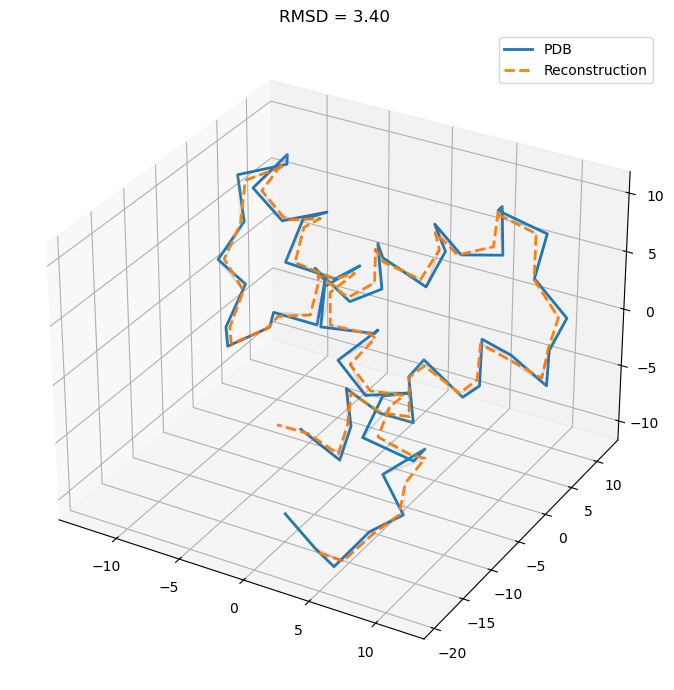

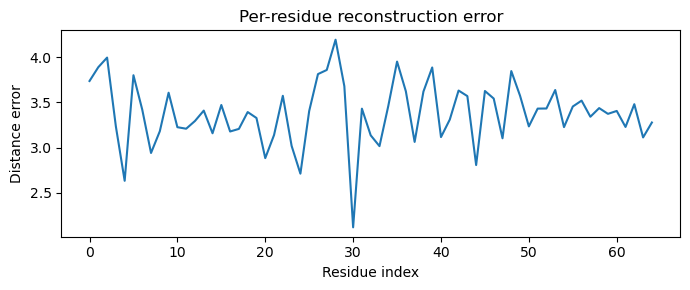

Scale factor: 0.9651812759043076
1.0363701111230577 4.794630778184077 {'pearson': np.float64(0.9572298886142545), 'mae': np.float64(1.2969496314133135), 'rmse': np.float64(1.8223207289458718)}


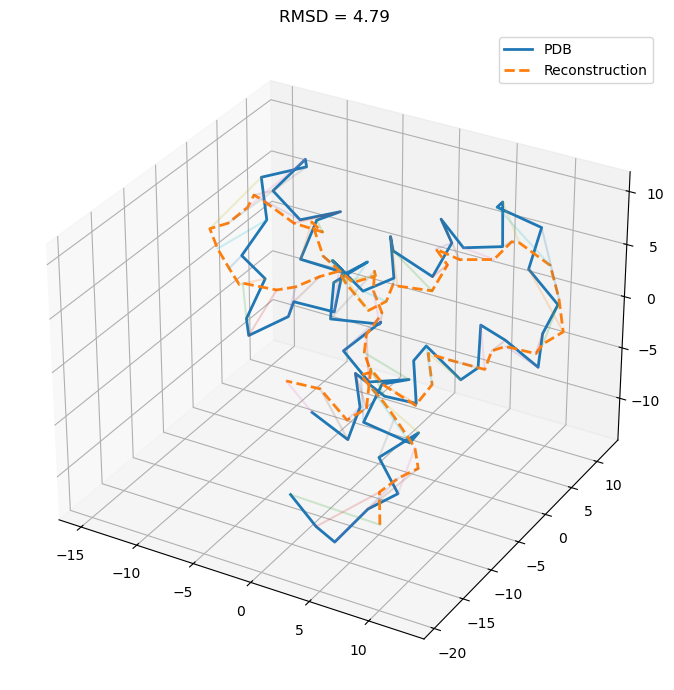

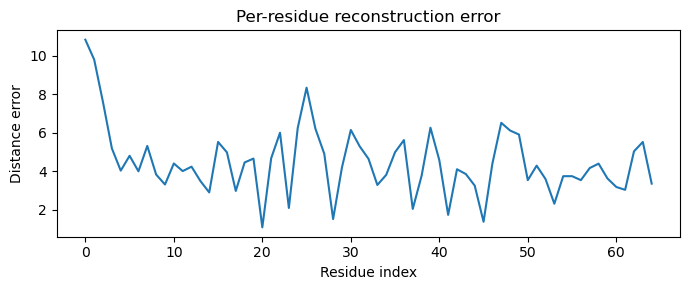

In [21]:
#real distance map


from sequenceHandler import mapPDBToHMM
pfam_id= "PF02899"
pdb_file = f"PDB/{pfam_id}.pdb"
chain_id = "A"
hmm_file = f"HMM/{pfam_id}.hmm"
hmm_file_2 = "None"        
output_map_file = "None"  




_, mi, aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='alpha')
true_dm = 8 * np.exp(np.asanyarray(true_dist_map))
#true_dm = 8 * (np.asanyarray(true_dist_map))


result = reconstruct_and_compare_with_mapPDBToHMM(true_dm, mi, pdb_file, chain_id, distType='alpha')
print(result["stress"], result["coord_rmsd"], result["distance_metrics"])

coords_1 = np.array(result["X_aligned"])

plot_3d_overlay(
    result["X_ref_centered"],
    result["X_aligned"],
    title=f"RMSD = {result['coord_rmsd']:.2f}"
)


plot_error_per_residue(
    result["X_ref_centered"],
    result["X_aligned"]
)

# Save reference
save_coords_as_pdb(result["X_ref_centered"], "reference.pdb")
#save reconstructed
save_coords_as_pdb(result["X_aligned"], "reconstructed.pdb")


#predicted distance map
pred_dm = 8 * np.exp(np.asanyarray(pred_dist_map))
#pred_dm = 8 * np.asanyarray(pred_dist_map)
result = reconstruct_and_compare_with_mapPDBToHMM(pred_dm, mi, pdb_file, chain_id, distType='alpha')
print(result["stress"], result["coord_rmsd"], result["distance_metrics"])


plot_3d_overlay(
    result["X_ref_centered"],
    result["X_aligned"],
    title=f"RMSD = {result['coord_rmsd']:.2f}"
)


plot_error_per_residue(
    result["X_ref_centered"],
    result["X_aligned"]
)


# Save reconstructed (aligned)
save_coords_as_pdb(result["X_aligned"], "reconstructed_GNN.pdb")


In [22]:
# print(result["X_ref_centered"])
# print(result["X_aligned"])

coords = np.array(result["X_ref_centered"])  # your first array
dists = np.linalg.norm(coords[1:] - coords[:-1], axis=1)
print(dists)


dists = np.linalg.norm(coords_1[1:] - coords_1[:-1], axis=1)
print(dists)

coords = np.array(result["X_aligned"])  # your second array
dists = np.linalg.norm(coords[1:] - coords[:-1], axis=1)
print(dists)

[3.81036507 3.79825059 3.79812688 3.80302562 3.80265506 3.79599666
 3.78877471 3.80630154 3.80534954 3.79220769 3.8122277  3.79699951
 3.78808964 3.80066916 3.79879272 3.79284031 3.8019088  3.79828927
 3.80457293 3.80014023 3.80562976 3.79036882 3.7985144  3.79828859
 3.8049883  3.80511406 3.80884598 3.80513179 3.80249929 3.80292715
 2.8981795  3.80209948 3.79445121 3.82308602 3.80480776 3.80332774
 3.79925054 3.80000065 3.79926239 3.8051288  3.79616136 3.79394199
 3.80159158 3.7992917  3.79615396 3.79498885 3.79822198 3.79374856
 3.79391028 3.81105515 3.80630234 3.79665059 3.80328042 3.80128336
 3.79247374 3.79779568 3.79681307 3.79771151 3.7813112  3.79420137
 3.80078502 3.80486988 3.80498765 3.79532014]
[2.88942264 3.2137282  3.30892253 2.98916154 2.62632297 2.64985963
 2.52186082 2.56262355 2.90441741 2.80299385 2.81521252 2.82858657
 3.08959123 2.90995421 2.92216232 3.06372717 2.98976092 3.07794862
 2.91460736 2.96095012 2.82209681 3.01760091 2.80261556 2.83279677
 3.21669901 3.46

In [28]:
k=5

tr=np.log(11/8)

prec=[]
prec_dca=[]
for batch in test_loader:
    batch = batch.to(device)

    #accuracy for a single batch
    with torch.no_grad():
        _, pred_dist = model(batch)
        scores = torch.sigmoid(pred_dist.squeeze(-1)) #inverse of the score, if they are close are good contacts
        scores_dca = batch.edge_attr[:, 0].squeeze(-1)  # DCA scores

    mask = batch.edge_mask & batch.pair_mask
    scores = scores[mask]
    scores_dca = scores_dca[mask]
    true_dist = batch.y.squeeze(-1)[mask]
    true_contacts = (true_dist < tr).float()
    
    L = batch.L
    topk = int(k * L)

    topk_idx = torch.topk(scores, k=min(topk, scores.numel()), largest=False).indices
    topk_idx_dca = torch.topk(scores_dca, k=min(topk, scores_dca.numel())).indices

    topk_true = true_contacts[topk_idx]
    topk_true_dca = true_contacts[topk_idx_dca]

    num_correct = topk_true.sum()
    precision = (num_correct / len(topk_true)).item()
    prec.append(precision)

    num_correct_dca = topk_true_dca.sum()
    precision_dca = (num_correct_dca / len(topk_true_dca)).item()
    prec_dca.append(precision_dca)


print(f"Precision of the GNN: {np.mean(prec)}")
print(f"Precision of the DCA: {np.mean(prec_dca)}")

Precision of the GNN: 0.8659353636396236
Precision of the DCA: 0.571620930917561
